<a href="https://colab.research.google.com/github/ayaz-ali-36/Data-Aanlysis/blob/main/Pandas/Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**Numpy**

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

clients = ['Ahmed', 'Sara', 'John', 'Mira', 'Bilal', 'Emma', 'Yusuf', 'Lisa', None]
projects = ['dashboard', 'cleaning', 'scraping', 'analysis', 'report']
methods = ['fixed', 'hourly', None]

n = 500

data = {
    'client': np.random.choice(clients, n),
    'project_type': np.random.choice(projects, n),
    'payment_usd': np.random.choice(
        [str(x) + '$' if np.random.random() < 0.1 else x
         for x in np.random.randint(50, 1000, n)], n),
    'days_taken': np.random.choice(
        [None if np.random.random() < 0.08 else x
         for x in np.random.randint(1, 30, n)], n),
    'pricing_method': np.random.choice(methods, n),
    'client_rating': np.random.choice(
        [None if np.random.random() < 0.15 else round(x, 1)
         for x in np.random.uniform(1, 5, n)], n),
    'repeat_client': np.random.choice(['yes', 'no', 'Yes', 'NO', None], n)
}

df = pd.DataFrame(data)

In [121]:
df.head()

,client,project_type,payment_usd,days_taken,pricing_method,client_rating,repeat_client
0,Yusuf,analysis,641,2,fixed,3.3,Yes
1,Mira,scraping,985,26,fixed,1.1,None
2,Lisa,report,738,22,hourly,4.5,NO
3,Bilal,analysis,872,12,hourly,2.6,no
4,Yusuf,scraping,572,28,fixed,1.6,Yes


In [122]:
df.isnull().sum()

,0
client,53
project_type,0
payment_usd,0
days_taken,40
pricing_method,165
client_rating,70
repeat_client,101


In [123]:
df.dtypes

,0
client,object
project_type,object
payment_usd,object
days_taken,object
pricing_method,object
client_rating,object
repeat_client,object


In [124]:
df['payment_usd']=(df['payment_usd'].astype(str).str.replace("$"," "))
df['payment_usd']=pd.to_numeric(df['payment_usd'], errors='coerce')


In [125]:
df.dtypes

,0
client,object
project_type,object
payment_usd,int64
days_taken,object
pricing_method,object
client_rating,object
repeat_client,object


In [126]:
df['repeat_client']=(df['repeat_client'].str.lower())

In [127]:
m_cr=df['client_rating'].median()
df['client_rating']=df['client_rating'].fillna(m_cr)

/tmp/ipykernel_7586/1298591099.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['client_rating']=df['client_rating'].fillna(m_cr)


In [128]:
m_dt=df['days_taken'].median()
df['days_taken']=df['days_taken'].fillna(m_dt)

/tmp/ipykernel_7586/2108871459.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['days_taken']=df['days_taken'].fillna(m_dt)


In [129]:
df=df[df['client'].notna()]

In [130]:
df=df.drop_duplicates()

In [15]:
df.shape

(447, 7)

In [131]:
df.isnull().sum()

,0
client,0
project_type,0
payment_usd,0
days_taken,0
pricing_method,153
client_rating,0
repeat_client,93


In [132]:
df['project_type'].value_counts()

,count
project_type,
dashboard,95
report,94
scraping,89
cleaning,85
analysis,84


Groupby and Aggregate

In [133]:
df.head()


,client,project_type,payment_usd,days_taken,pricing_method,client_rating,repeat_client
0,Yusuf,analysis,641,2.0,fixed,3.3,yes
1,Mira,scraping,985,26.0,fixed,1.1,None
2,Lisa,report,738,22.0,hourly,4.5,no
3,Bilal,analysis,872,12.0,hourly,2.6,no
4,Yusuf,scraping,572,28.0,fixed,1.6,yes


In [134]:
df.groupby('project_type')['payment_usd'].mean().sort_values(ascending=False)

,payment_usd
project_type,
scraping,547.988764
cleaning,536.247059
analysis,518.416667
dashboard,506.294737
report,487.989362


In [135]:
df.groupby('client')['payment_usd'].sum().sort_values(ascending=False)

,payment_usd
client,
Ahmed,36043
John,31588
Yusuf,31272
Bilal,30228
Mira,28456
Lisa,26288
Emma,24324
Sara,23669


In [136]:
df['pricing_method'].value_counts()

,count
pricing_method,
fixed,148
hourly,146


In [137]:
 df.groupby('project_type')[['payment_usd', 'days_taken']].mean()


,payment_usd,days_taken
project_type,,
analysis,518.416667,15.892857
cleaning,536.247059,15.941176
dashboard,506.294737,15.178947
report,487.989362,13.755319
scraping,547.988764,16.179775


In [138]:
df.groupby('project_type')['client_rating'].mean()

,client_rating
project_type,
analysis,2.984524
cleaning,2.957647
dashboard,2.996842
report,3.093617
scraping,3.151685


**EDA**

In [139]:
print(df.shape)
print(df.dtypes)

(447, 7)
client             object
project_type       object
payment_usd         int64
days_taken        float64
pricing_method     object
client_rating     float64
repeat_client      object
dtype: object


In [140]:
df.head()

,client,project_type,payment_usd,days_taken,pricing_method,client_rating,repeat_client
0,Yusuf,analysis,641,2.0,fixed,3.3,yes
1,Mira,scraping,985,26.0,fixed,1.1,None
2,Lisa,report,738,22.0,hourly,4.5,no
3,Bilal,analysis,872,12.0,hourly,2.6,no
4,Yusuf,scraping,572,28.0,fixed,1.6,yes


In [141]:
df.describe()

,payment_usd,days_taken,client_rating
count,447.000000,447.000000,447.000000
mean,518.720358,15.357942,3.038255
std,280.333746,8.118341,1.056897
min,52.000000,1.000000,1.000000
25%,275.500000,9.000000,2.100000
50%,516.000000,15.000000,3.100000
75%,788.000000,22.500000,4.000000
max,998.000000,29.000000,5.000000


In [142]:
df.loc[4,"client"]

'Yusuf'

In [143]:
df.iloc[1:1]

,client,project_type,payment_usd,days_taken,pricing_method,client_rating,repeat_client


In [144]:
print(df.isnull().sum())

client              0
project_type        0
payment_usd         0
days_taken          0
pricing_method    153
client_rating       0
repeat_client      93
dtype: int64


In [145]:
print('Mean:', df['payment_usd'].mean())
print('Median:', df['payment_usd'].median())
print('Std:', df['payment_usd'].std())

Mean: 518.7203579418344
Median: 516.0
Std: 280.3337458618386


In [51]:
print(df.corr(numeric_only=True))

               payment_usd  days_taken  client_rating
payment_usd       1.000000    0.018412       0.034881
days_taken        0.018412    1.000000       0.086699
client_rating     0.034881    0.086699       1.000000


Visualization

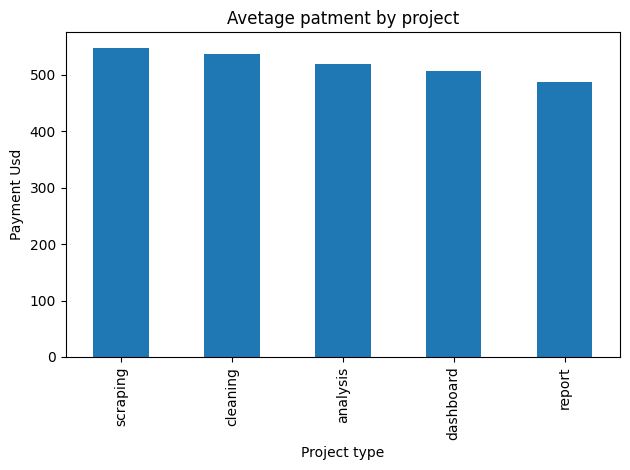

In [146]:
df.groupby('project_type')['payment_usd'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title("Avetage patment by project")
plt.xlabel("Project type")
plt.ylabel('Payment Usd')
plt.tight_layout()
plt.show()

<Axes: >

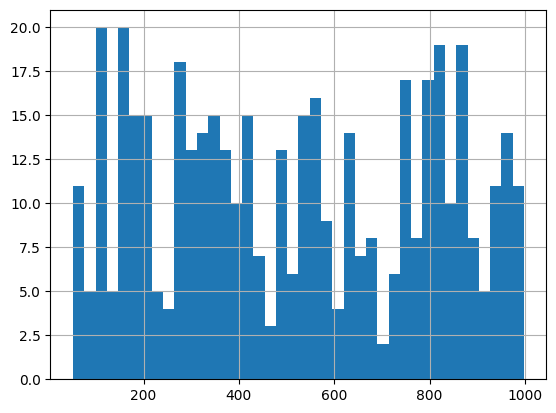

In [147]:
df["payment_usd"].hist(bins=40)

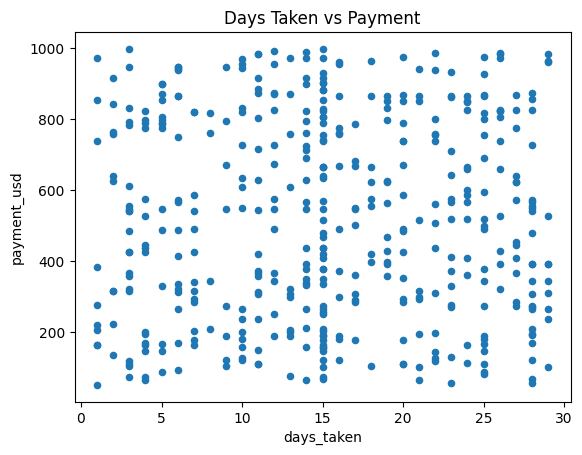

In [148]:
# df.plot(kind='scatter ',x='payment_usd',y='days_taken')
df.plot(kind='scatter', x='days_taken', y='payment_usd')
plt.title('Days Taken vs Payment')
plt.show()

In [149]:
df.head()

,client,project_type,payment_usd,days_taken,pricing_method,client_rating,repeat_client
0,Yusuf,analysis,641,2.0,fixed,3.3,yes
1,Mira,scraping,985,26.0,fixed,1.1,None
2,Lisa,report,738,22.0,hourly,4.5,no
3,Bilal,analysis,872,12.0,hourly,2.6,no
4,Yusuf,scraping,572,28.0,fixed,1.6,yes


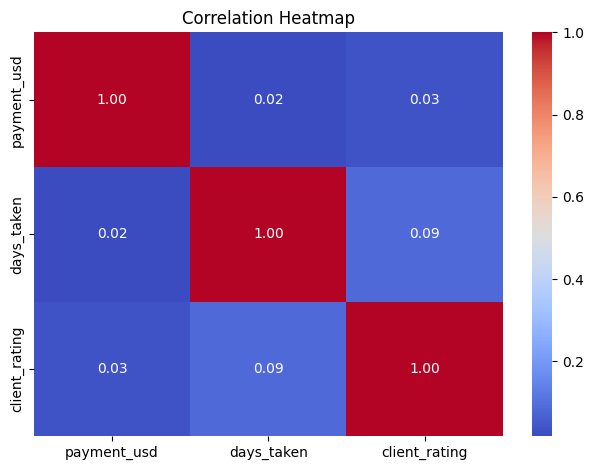

In [152]:

# plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.savefig('heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

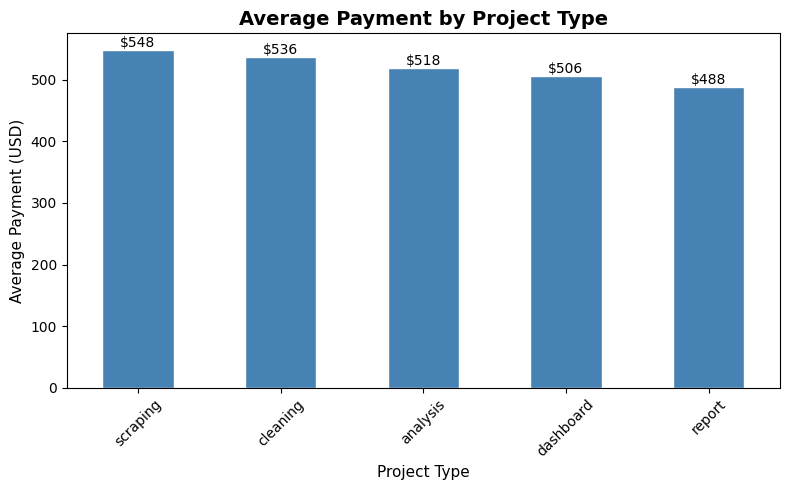

In [151]:
# Professional bar chart
ax = df.groupby('project_type')['payment_usd'].mean()\
       .sort_values(ascending=False).plot(kind='bar',
                                          color='steelblue',
                                          figsize=(8,5),
                                          edgecolor='white')
ax.set_title('Average Payment by Project Type', fontsize=14, fontweight='bold')
ax.set_xlabel('Project Type', fontsize=11)
ax.set_ylabel('Average Payment (USD)', fontsize=11)
ax.tick_params(axis='x', rotation=45)

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f'${p.get_height():.0f}',
                (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('payment_by_project.png', dpi=150)
plt.show()